In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, ScalarFormatter
import numpy as np
import pandas as pd
import os

In [2]:
N_arr = [2, 3, 4, 5, 7, 10, 14, 20, 30, 40, 50, 100]
N_tabdiff_old_arr = [2, 5, 10, 20, 30, 40, 50, 100]
N_tabdiff_arr = [3, 4, 5, 7, 10, 14, 20, 30, 40, 50, 100]
N_new_arr = [2, 3, 4, 5, 7, 10, 14, 20, 30, 40, 50, 100]

In [3]:
path_tabdiff_old = '/home/okashurin/okashurin/TabDiff/eval/report_runs/try_1/'
path_tabdiff = '/home/okashurin/okashurin/TabDiff/eval/report_runs/tabdiff/'
path_vddpm = '/home/okashurin/okashurin/TabDiff/eval/report_runs/rec_2_heads_big_kl_0.1_decay_xt_t_variational'

In [4]:
def get_data(path, N_arr):
    shape_arr = []
    trend_arr = []
    mle_arr = []
    c2st_arr = []

    std_shape_arr = []
    std_trend_arr = []
    std_mle_arr = []
    std_c2st_arr = []

    for i in range(len(N_arr)):
        N = N_arr[i]

        df_path = os.path.join(path, f'N_{N}/adult/avg_std.csv')
        df = pd.read_csv(df_path, skiprows=1, header=None)

        shape_arr.append(df.iloc[0, 1])
        trend_arr.append(df.iloc[1, 1])
        mle_arr.append(df.iloc[2, 1])
        c2st_arr.append(df.iloc[3, 1])

        std_shape_arr.append(df.iloc[0, 2])
        std_trend_arr.append(df.iloc[1, 2])
        std_mle_arr.append(df.iloc[2, 2])
        std_c2st_arr.append(df.iloc[3, 2])

    shape_arr = np.array(shape_arr)
    trend_arr = np.array(trend_arr)
    mle_arr = np.array(mle_arr)
    c2st_arr = np.array(c2st_arr)

    std_shape_arr = np.array(std_shape_arr)
    std_trend_arr = np.array(std_trend_arr)
    std_mle_arr = np.array(std_mle_arr)
    std_c2st_arr = np.array(std_c2st_arr)

    return {
        'shape': shape_arr,
        'trend': trend_arr,
        'mle': mle_arr,
        'c2st': c2st_arr,
        'std_shape': std_shape_arr,
        'std_trend': std_trend_arr,
        'std_mle': std_mle_arr,
        'std_c2st': std_c2st_arr
    }

In [5]:
data_tabdiff_old = get_data(path_tabdiff_old, N_tabdiff_old_arr)
data_tabdiff = get_data(path_tabdiff, N_tabdiff_arr)
data_vddpm = get_data(path_vddpm, N_arr)

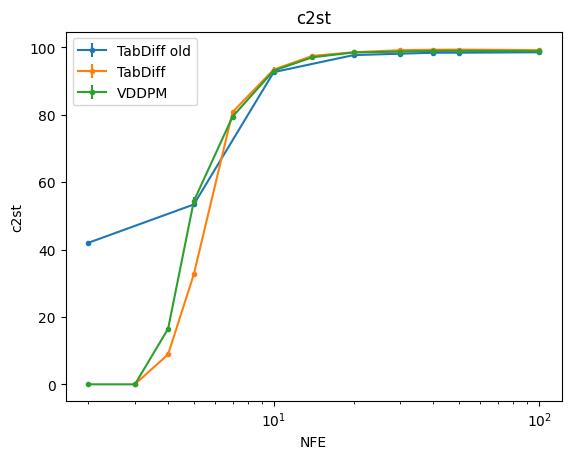

In [6]:
matric = 'c2st'

plt.errorbar(N_tabdiff_old_arr, data_tabdiff_old[matric], yerr=data_tabdiff_old[f'std_{matric}'], label='TabDiff old', marker='.')
plt.errorbar(N_tabdiff_arr, data_tabdiff[matric], yerr=data_tabdiff[f'std_{matric}'], label='TabDiff', marker='.')
plt.errorbar(N_arr, data_vddpm[matric], yerr=data_vddpm[f'std_{matric}'], label='VDDPM', marker='.')
plt.title(matric)
plt.xlabel('NFE')
plt.ylabel(matric)
# plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.show()

In [7]:
def plot_all_metrics(data_list, N_arr_list, labels_list, reverse=False):
    metrics = ['shape', 'trend', 'mle', 'c2st']

    metric_labels = {
        'shape': 'Shape',
        'trend': 'Trend',
        'mle': 'MLE',
        'c2st': 'C2ST'
    }

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for i, (ax, metric) in enumerate(zip(axes, metrics)):

        for data, N_arr, label in zip(data_list, N_arr_list, labels_list):
            if reverse:
                if metric == 'c2st':
                    ax.errorbar(
                        N_arr,
                        100 - data[metric],
                        yerr=data[f'std_{metric}'],
                        label=label,
                        marker='.'
                    )
                elif metric == 'mle':
                    ax.errorbar(
                        N_arr,
                        1 - data[metric],
                        yerr=data[f'std_{metric}'],
                        label=label,
                        marker='.'
                    )
                else:
                    ax.errorbar(
                        N_arr,
                        data[metric],
                        yerr=data[f'std_{metric}'],
                        label=label,
                        marker='.'
                    )
            else:
                ax.errorbar(
                    N_arr,
                    data[metric],
                    yerr=data[f'std_{metric}'],
                    label=label,
                    marker='.'
                )


        if reverse and metric in ['c2st', 'mle']:
            if metric == 'c2st':
                ax.set_title(f'100 - {metric_labels[metric]} ↓')
                ax.set_ylabel(f'100 - {metric_labels[metric]} ↓')
            else:
                ax.set_title(f'1 - {metric_labels[metric]} ↓')
                ax.set_ylabel(f'1 - {metric_labels[metric]} ↓')
        else:
            ax.set_title(f"{metric_labels[metric]} ↓")
            ax.set_ylabel(f"{metric_labels[metric]} ↓")

        ax.set_xlabel('NFE')

        ax.set_xscale('log')
        ax.set_yscale('log')

        # if metric == 'c2st':
        #     ax.set_ylim(1e-1, 1e2 + 30)

        # major + minor tick locations
        ax.xaxis.set_major_locator(LogLocator(base=10.0))
        ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=range(2, 10)))

        ax.yaxis.set_major_locator(LogLocator(base=10.0))
        ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=range(2, 10)))

        # standard number formatting instead of scientific notation
        xfmt = ScalarFormatter()
        xfmt.set_scientific(False)
        xfmt.set_useOffset(False)

        yfmt = ScalarFormatter()
        yfmt.set_scientific(False)
        yfmt.set_useOffset(False)

        ax.xaxis.set_major_formatter(xfmt)
        ax.xaxis.set_minor_formatter(xfmt)
        ax.yaxis.set_major_formatter(yfmt)
        ax.yaxis.set_minor_formatter(yfmt)

        # show minor tick labels
        ax.tick_params(axis='both', which='minor', labelsize=8)
        ax.tick_params(axis='both', which='major', labelsize=10)

        ax.legend()

    plt.tight_layout()
    plt.show()

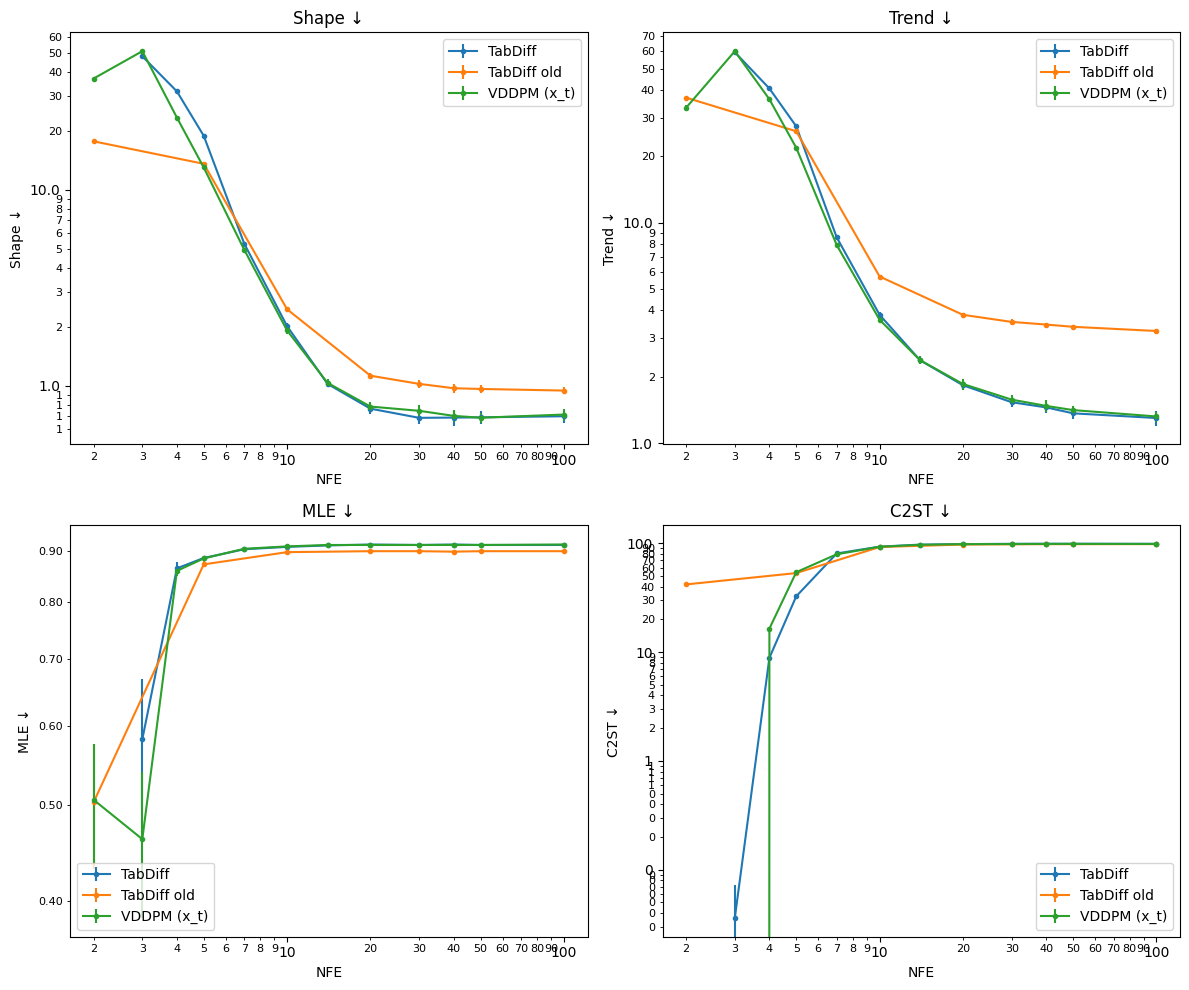

In [8]:
plot_all_metrics(
    [data_tabdiff, data_tabdiff_old, data_vddpm],
    [N_tabdiff_arr, N_tabdiff_old_arr, N_arr],
    ['TabDiff', 'TabDiff old', 'VDDPM (x_t)']
)

## Different parametrizations

In [22]:
N_par_arr = [4, 5, 7, 10, 14, 20, 30, 40, 50, 100]

path_vddpm_x0_xt_t = '/home/okashurin/okashurin/TabDiff/eval/report_runs/rec_2_heads_big_kl_0.01_variational'
data_vddpm_x0_xt_t = get_data(path_vddpm_x0_xt_t, N_par_arr)

path_vddpm_x0 = '/home/okashurin/okashurin/TabDiff/eval/report_runs/rec_2_heads_big_kl_0.01_x0_variational'
data_vddpm_x0 = get_data(path_vddpm_x0, N_par_arr)

# path_vddpm_x0_t = '/home/okashurin/okashurin/TabDiff/eval/report_runs/rec_2_heads_big_kl_0.01_x0_t_variational'
# data_vddpm_x0_t = get_data(path_vddpm_x0_t, N_par_arr)

path_vddpm_xt_t = '/home/okashurin/okashurin/TabDiff/eval/report_runs/rec_2_heads_big_kl_0.01_xt_t_variational'
data_vddpm_xt_t = get_data(path_vddpm_xt_t, N_par_arr)

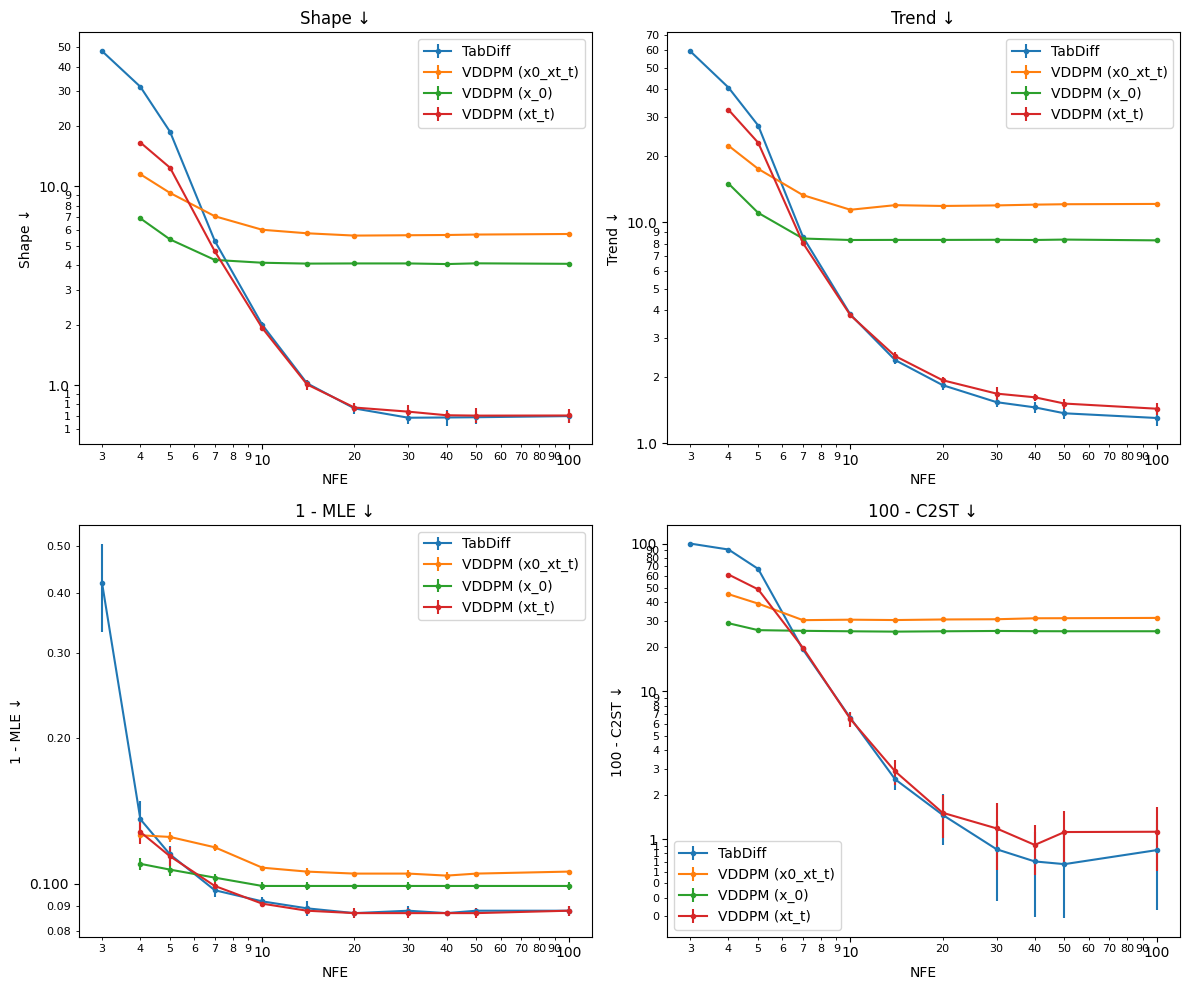

In [23]:
plot_all_metrics(
    [
        data_tabdiff,
        data_vddpm_x0_xt_t,
        data_vddpm_x0,
        data_vddpm_xt_t,

    ],
    [
        N_tabdiff_arr,
        N_par_arr,
        N_par_arr,
        N_par_arr,
    ],
    [
        'TabDiff',
        'VDDPM (x0_xt_t)',
        'VDDPM (x_0)',
        'VDDPM (xt_t)'
    ],
    reverse=True
)

In [16]:
path_ld_2 = "/home/okashurin/okashurin/TabDiff/eval/report_runs/rec_2_heads_big_kl_0.1_decay_x0_ld_2_variational"
data_ld_2 = get_data(path_ld_2, N_new_arr)

path_ld_4 = "/home/okashurin/okashurin/TabDiff/eval/report_runs/rec_2_heads_big_kl_0.1_decay_x0_ld_4_variational"
data_ld_4 = get_data(path_ld_4, N_new_arr)

path_ld_8 = "/home/okashurin/okashurin/TabDiff/eval/report_runs/rec_2_heads_big_kl_0.1_decay_x0_ld_8_variational"
data_ld_8 = get_data(path_ld_8, N_new_arr)

path_ld_16 = "/home/okashurin/okashurin/TabDiff/eval/report_runs/rec_2_heads_big_kl_0.1_decay_x0_ld_16_variational"
data_ld_16 = get_data(path_ld_16, N_new_arr)

path_ld_32 = "/home/okashurin/okashurin/TabDiff/eval/report_runs/rec_2_heads_big_kl_0.1_decay_x0_ld_32_variational"
data_ld_32 = get_data(path_ld_32, N_new_arr)

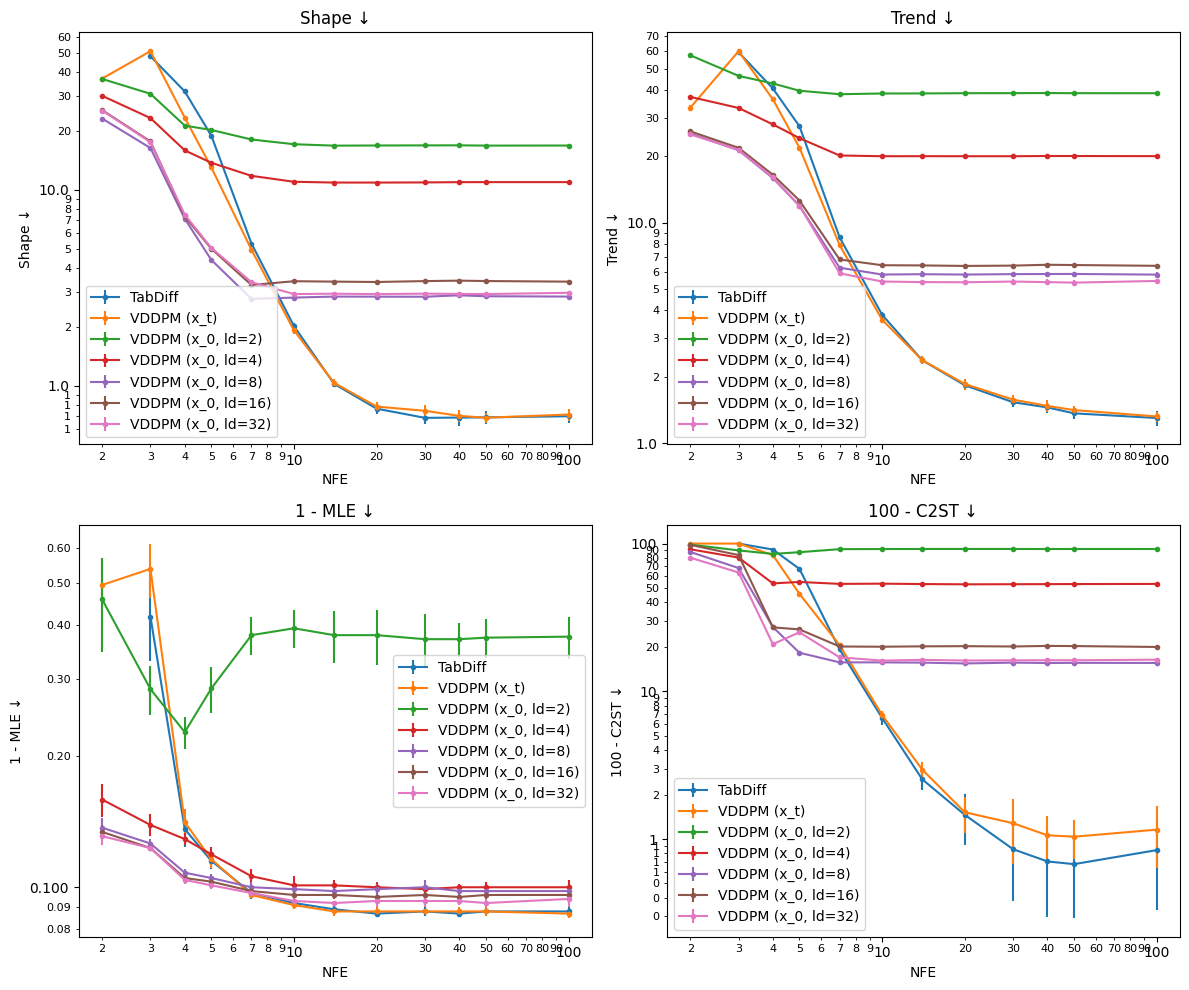

In [10]:
plot_all_metrics(
    [data_tabdiff, data_vddpm, data_ld_2, data_ld_4, data_ld_8, data_ld_16, data_ld_32],
    [N_tabdiff_arr, N_arr, N_new_arr, N_new_arr, N_new_arr, N_new_arr, N_new_arr],
    ['TabDiff', 'VDDPM (x_t)', 'VDDPM (x_0, ld=2)', 'VDDPM (x_0, ld=4)', 'VDDPM (x_0, ld=8)', 'VDDPM (x_0, ld=16)', 'VDDPM (x_0, ld=32)'],
    reverse=True
)

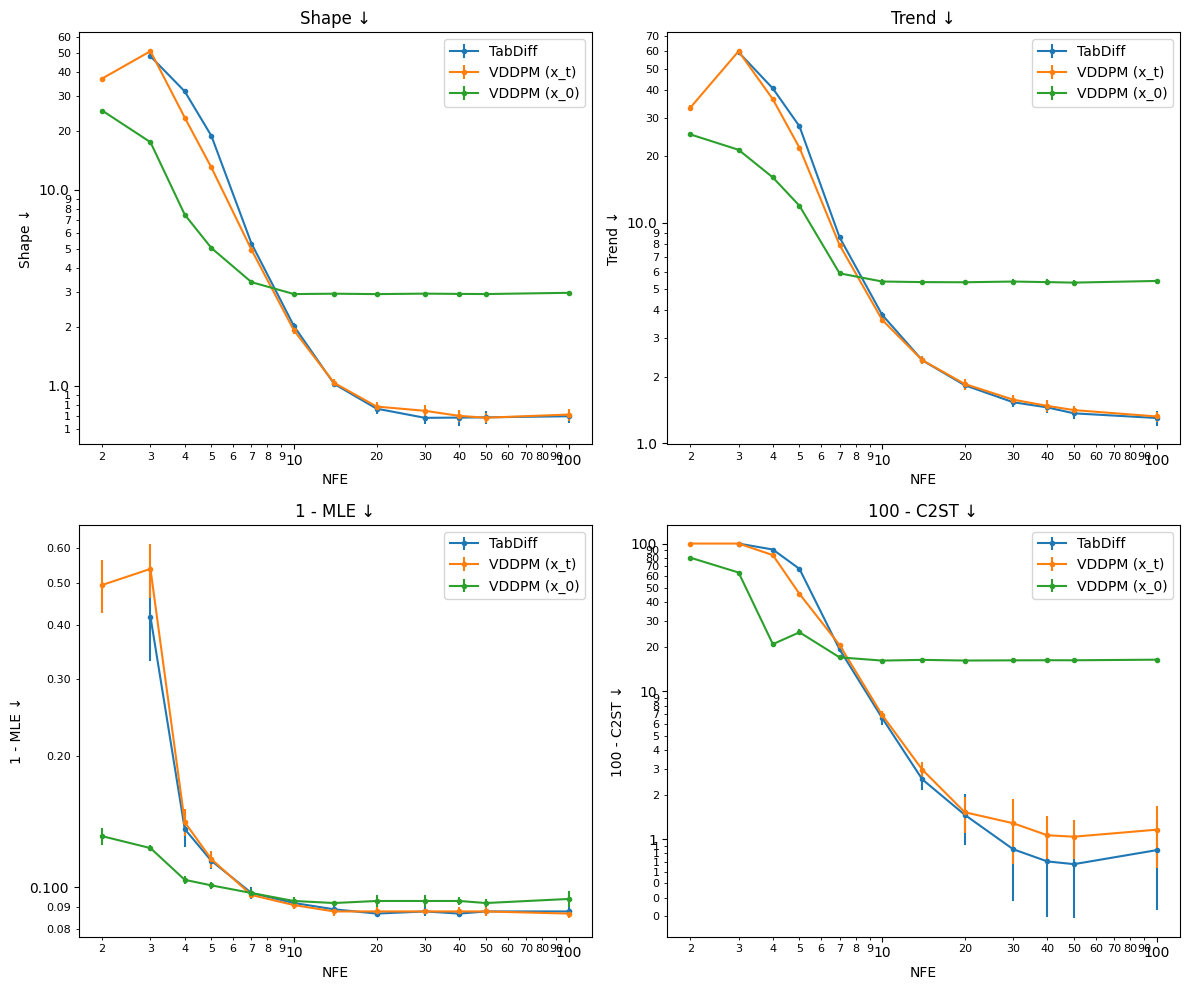

In [11]:
plot_all_metrics(
    [data_tabdiff, data_vddpm, data_ld_32],
    [N_tabdiff_arr, N_arr, N_new_arr],
    ['TabDiff', 'VDDPM (x_t)', 'VDDPM (x_0)'],
    reverse=True
)

In [12]:
N_cfg_arr = [4, 5, 7, 10, 14, 20, 30, 40, 50, 100]

In [13]:
path_cfg_1 = "/home/okashurin/okashurin/TabDiff/eval/report_runs/rec_2_heads_big_kl_0.1_decay_x0_ld_32_lcfg_variational/lcfg_0.1"
data_cdf_1 = get_data(path_cfg_1, N_cfg_arr)

path_cfg_3 = "/home/okashurin/okashurin/TabDiff/eval/report_runs/rec_2_heads_big_kl_0.1_decay_x0_ld_32_lcfg_variational/lcfg_0.3"
data_cdf_3 = get_data(path_cfg_3, N_cfg_arr)

path_cfg_5 = "/home/okashurin/okashurin/TabDiff/eval/report_runs/rec_2_heads_big_kl_0.1_decay_x0_ld_32_lcfg_variational/lcfg_0.5"
data_cdf_5 = get_data(path_cfg_5, N_cfg_arr)

path_cfg_7 = "/home/okashurin/okashurin/TabDiff/eval/report_runs/rec_2_heads_big_kl_0.1_decay_x0_ld_32_lcfg_variational/lcfg_0.7"
data_cdf_7 = get_data(path_cfg_7, N_cfg_arr)

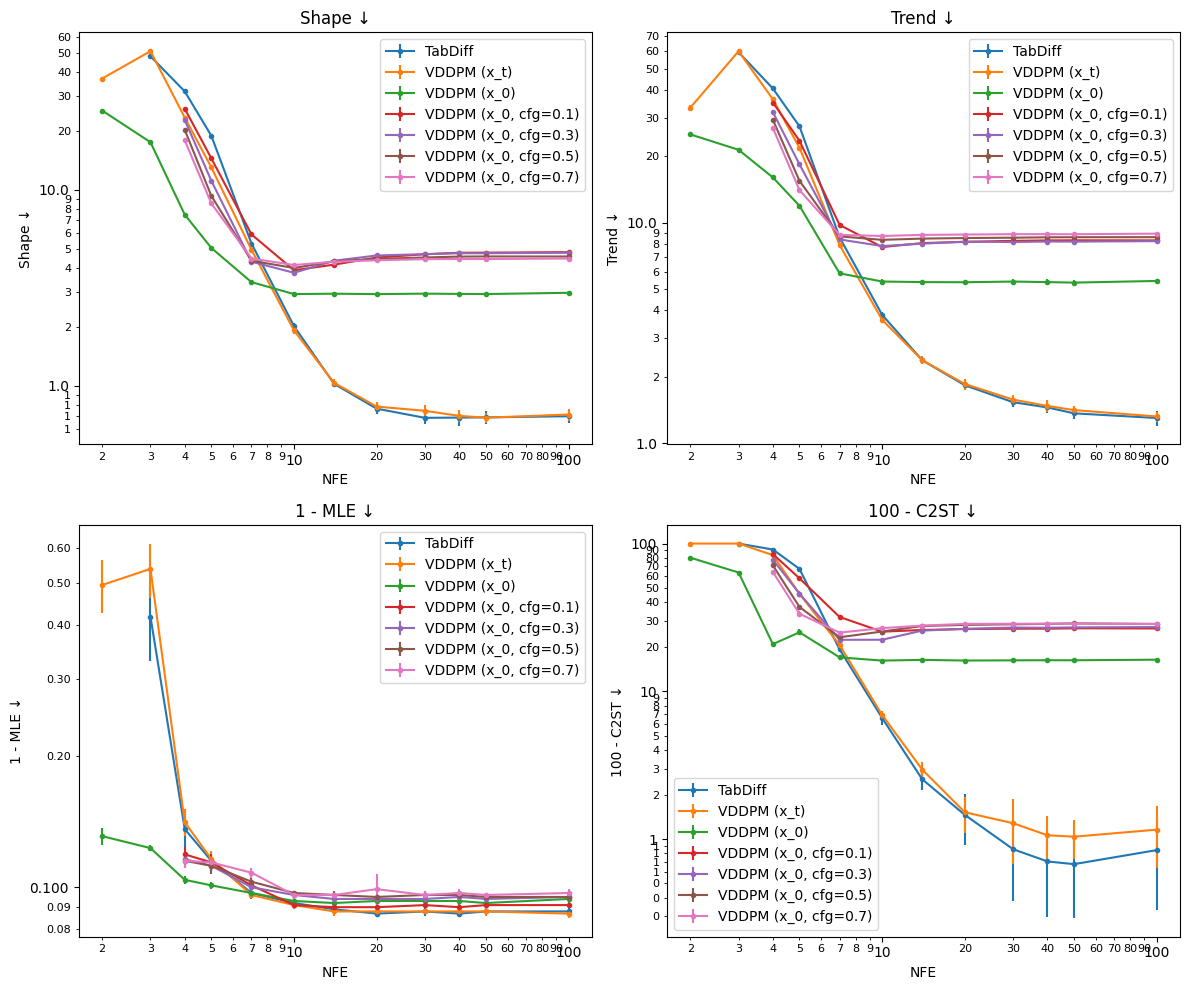

In [14]:
plot_all_metrics(
    [
        data_tabdiff,
        data_vddpm,
        data_ld_32,
        data_cdf_1,
        data_cdf_3,
        data_cdf_5,
        data_cdf_7
    ],
    [
        N_tabdiff_arr,
        N_arr,
        N_new_arr,
        N_cfg_arr,
        N_cfg_arr,
        N_cfg_arr,
        N_cfg_arr
    ],
    [
        'TabDiff',
        'VDDPM (x_t)',
        'VDDPM (x_0)',
        'VDDPM (x_0, cfg=0.1)',
        'VDDPM (x_0, cfg=0.3)',
        'VDDPM (x_0, cfg=0.5)',
        'VDDPM (x_0, cfg=0.7)'
    ],
    reverse=True
)

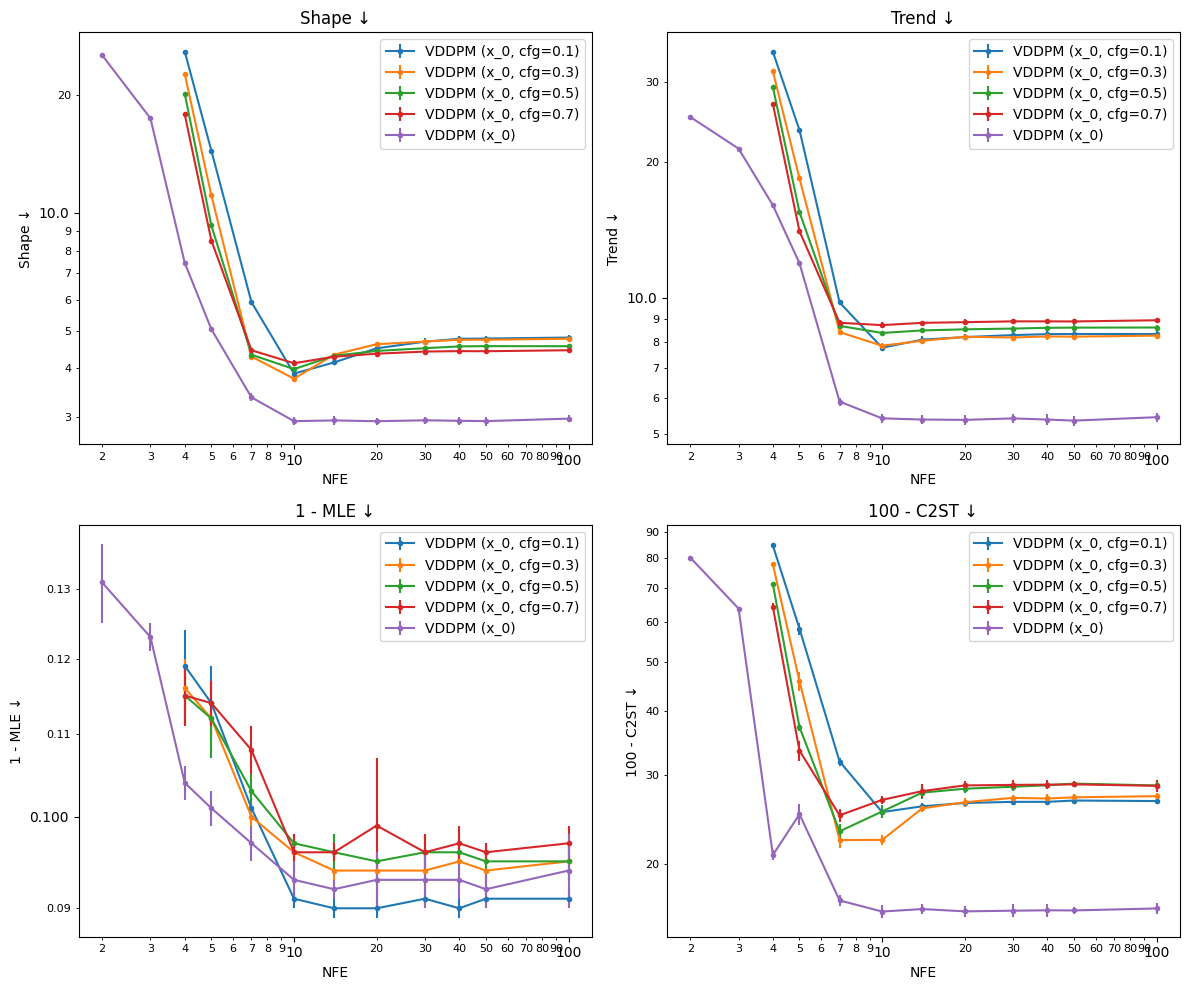

In [24]:
plot_all_metrics(
    [
        data_cdf_1,
        data_cdf_3,
        data_cdf_5,
        data_cdf_7,
        data_ld_32
    ],
    [
        N_cfg_arr,
        N_cfg_arr,
        N_cfg_arr,
        N_cfg_arr,
        N_new_arr
    ],
    [
        'VDDPM (x_0, cfg=0.1)',
        'VDDPM (x_0, cfg=0.3)',
        'VDDPM (x_0, cfg=0.5)',
        'VDDPM (x_0, cfg=0.7)',
        'VDDPM (x_0)'
    ],
    reverse=True
)